# USES CALC V2 and MC V4 AND NEW REBOUND

In [19]:
%load_ext autoreload
%autoreload 2
import numpy as np
from scipy.optimize import brentq
import matplotlib.pyplot as plt
from astropy import constants as const
from astropy import units as u
from src.simulations.Rebound_v4 import OrbitalSimulation
from numpy.random import SeedSequence, Generator, PCG64
import src.utils.calculations_v3 as calc
import multiprocessing
import datetime
from numpy.random import SeedSequence, Generator, PCG64
import src.simulations.MonteCarlo_impsamp_v4 as MCi
import src.configurations.Configuration as conf
import src.analysis.Analysis as anl
import src.plotting.Plotting as pl
import datetime as dt
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Simulation Runs

In [20]:
mPBH_grid = np.logspace(np.log10(1e-3), np.log10(10), 5) * const.M_sun.value  # from 1e-10 to 1 solar mass
print(mPBH_grid)

[1.98840987e+27 1.98840987e+28 1.98840987e+29 1.98840987e+30
 1.98840987e+31]


In [21]:
run_dict = {}
for i, mPBH in enumerate(mPBH_grid):

    seed = i + 100  # Just a way to get different seeds
    name = f"OmegaCenturiBH_MS_s{seed}_calcv3_MCv4_reboundV4"
    configuration = conf.Configuration(name=name, seed=seed, importance_sampling=True)
    configuration.set_system_param('mC', mPBH)  # Mass of light PBH
    configuration.set_simulation_param('sample_size', 200)  # Mass of light PBH
    configuration.set_simulation_param('max_trials', 1000000000)  # Mass of light PBH
    max_v_default = configuration.get_simulation_param(all=True)['v_inf_grid'][-1]
    configuration.set_simulation_param('max_v', 0.75 * max_v_default)
    configuration.print_configuration()
    run_dict[name] = {'name': name, 'seed': seed, 'configuration': configuration}
    print(f"Prepared configuration for mPBH = {mPBH / const.M_sun.value} solar masses.\n")


Updated v_inf_grid_params 'max_v' to 254539.28999999998 and regenerated v_inf_grid.
System Parameters:
  mA: 1.6304960939724018e+34
  mB: 1.988409870698051e+31
  mC: 1.988409870698051e+27
  aB: 92562705350480.95
  rB: 3478500000.0
  vB: 110000.0
  eB: 0.2
  iB: 0
  epsilon: 0.05947540101248887
  seed_base: 100
  name: OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4

Simulation Parameters:
  trials: 10000000
  max_trials: 1000000000
  max_execution_time: 3600
  sample_size: 200
  max_e: 1.0
  vDM: 220000.0
  v_inf_grid_params: {'min_v': 1000, 'max_v': np.float64(254539.28999999998), 'n_v': 10}
  importance_sampling: True
  v_inf_grid: [  1000.          29171.03222222  57342.06444444  85513.09666667
 113684.12888889 141855.16111111 170026.19333333 198197.22555556
 226368.25777778 254539.29      ]
Prepared configuration for mPBH = 0.001 solar masses.

Updated v_inf_grid_params 'max_v' to 254539.28999999998 and regenerated v_inf_grid.
System Parameters:
  mA: 1.6304960939724018e+34
  mB: 1.98

In [22]:
def mc_worker(pars):
    conf, child_ss, v_inf = pars
    rng = Generator(PCG64(child_ss)) # independent per worker
    simulation = MCi.MonteCarloSimulation(conf, rng)
    return simulation.run_monte_carlo_simulation(v_inf)

if __name__ == "__main__":
    all_pars = []
    start_time = datetime.datetime.now()
    
    for run in run_dict.values():
        print(f"Preparing simulation: {run['name']}")
        configuration_ = run['configuration']
        seed_ = run['seed']
        v_inf_grid_ = configuration_.get_simulation_param('v_inf_grid')
        base_ss = SeedSequence(seed_)
        print(f'  {len(v_inf_grid_)} v_inf values: {v_inf_grid_[0]:.1f} to {v_inf_grid_[-1]:.1f} m/s')
        child_sss = base_ss.spawn(len(v_inf_grid_))
        pars = [(configuration_, child_sss[i], v_inf_grid_[i]) for i in range(len(v_inf_grid_))]
        all_pars.extend(pars)
    
    num_cores = 50
    print(f'\n{"="*60}')
    print(f'Total simulations to run: {len(all_pars)}')
    print(f'Configurations: {len(run_dict)}')
    print(f'CPU cores: {num_cores}')
    print(f'{"="*60}\n')
    
    with multiprocessing.Pool(processes=num_cores) as pool:
        results = pool.map(mc_worker, all_pars)
    
    elapsed_time = datetime.datetime.now() - start_time
    print(f'\n{"="*60}')
    print(f'✓ All simulations complete!')
    print(f'Total time: {elapsed_time} ({elapsed_time.total_seconds()/60:.2f} minutes)')
    print(f'Completed {len(all_pars)} simulations across {len(run_dict)} configurations')
    print(f'{"="*60}')

Preparing simulation: OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s101_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s102_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s103_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s
Preparing simulation: OmegaCenturiBH_MS_s104_calcv3_MCv4_reboundV4
  10 v_inf values: 1000.0 to 254539.3 m/s

Total simulations to run: 50
Configurations: 5
CPU cores: 50



for v_inf=254.53928999999997 km/s and mC 0.001 M_sun MC capture cross-section: 1.2062417556594076e+25 m^2
for v_inf=254.53928999999997 km/s and mC 0.001 M_sun MC capture cross-section (dσ avg): 7.46279958683866e+20 m^2
for v_inf=254.53928999999997 km/s and mC 0.001 M_sun MC capture cross-section (b_max): 2.6442003001455883e+21 m^2
Number of captured orbits: 200, e condition met: 200, out of 489 samples.
for v_inf=226.36825777777776 km/s and mC 0.001 M_sun MC capture cross-section: 5.851708517038197e+24 m^2
for v_inf=226.36825777777776 km/s and mC 0.001 M_sun MC capture cross-section (dσ avg): 7.99502940683568e+20 Results saved for v_inf=254.53928999999997 km/s with N=489 trials.
m^2
for v_inf=226.36825777777776 km/s and mC 0.001 M_sun MC capture cross-section (b_max): 2.319598385659909e+21 m^2
Number of captured orbits: 200, e condition met: 201, out of 1008 samples.
for v_inf=226.36825777777776 km/s and mC 0.01 M_sun MC capture cross-section:Results saved for v_inf=226.36825777777776 

In [23]:
for run in run_dict.values():

    configuration = run['configuration']
    name = run['name']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    mc = analysis.get_mc_results()
    sampled_mc = analysis.get_sampled_mc_results()
    run_dict[name]['sampled_mc'] = sampled_mc
    # Debug: Check MC data structure and read inclinations

        

    

Loading MC results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Rebound_Simulation_Results/
captured objects for v_inf = v170 km/s: 200
v_inf = v170 km/s: sampled 200 captured objects
captured objects for v_inf = v255 km/s: 200
v_inf = v255 km/s: sampled 200 captured objects
captured objects for v_inf = v226 km/s: 200
v_inf = v226 km/s: sampled 200 captured objects
captured objects for v_inf = v57 km/s: 200
v_inf = v57 km/s: sampled 200 captured objects
captured objects for v_inf = v114 km/s: 200
v_inf = v114 km/s: sampled 200 captured objects
captured objects for v_inf = v142 km/s: 200
v_inf = v142 km/s: sampled 200 captured objects
captured objects for v_inf = v86 km/s: 200
v_inf = v86 km/s: sampled 200 captured objects
captured objects for v_inf = v1 km/s: 200
v_inf = v1 km/s: sampled 200 captured objects
captur

In [24]:
# CORRECTED VERSION - Option 2: Process all runs together (more efficient)
def check_result_exists_v2(configuration, v_inf_kms, i, seed):
    """Check if a result file already exists"""
    v_str = f"{v_inf_kms:.0f}"
    save_dir = configuration.get_save_dir_rebound()
    dir_npz = os.path.join(save_dir, f"v{v_str}")
    out_npz = os.path.join(dir_npz, f"sim_{i}_{seed}.npz")
    return os.path.isfile(out_npz)

def check_condition_in_existing_result(configuration, v_inf_kms, i, seed, condition_key, condition_value):
    """Check if a specific condition is met in an existing result file"""
    v_str = f"{v_inf_kms:.0f}"
    save_dir = configuration.get_save_dir_rebound()
    dir_npz = os.path.join(save_dir, f"v{v_str}")
    out_npz = os.path.join(dir_npz, f"sim_{i}_{seed}.npz")
    
    if not os.path.isfile(out_npz):
        return False  # File doesn't exist, so condition can't be met
    
    try:
        data = np.load(out_npz, allow_pickle=True)
        result_list = data.files  # Assuming result is stored as a dict
        print(f"Checking {condition_key} in {out_npz}: found keys {result_list}")
        return condition_value in data[condition_key]
    except Exception as e:
        print(f"Error checking condition in {out_npz}: {e}")
        return False

def rebound_worker_v2(pars):
    configuration, child_ss, i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B, a_c, e_c = pars
    rng = Generator(PCG64(child_ss))
    simulation = OrbitalSimulation(configuration=configuration, rng=rng)
    return simulation.run_orbital_integration(i, v_inf, lambda1, beta, phi, b, pos_C, v_C, pos_B, v_B, a_c, e_c, check_exists=False)

if __name__ == "__main__":
    overall_start = datetime.datetime.now()
    num_cores = 50
    
    # Build parameter list for ALL runs together
    all_pars = []
    run_info = []  # Track which parameters belong to which run
    
    for run in run_dict.values():
        print(f"Preparing {run['name']}...")
        conf_ = run['configuration']
        seed_ = run['seed']
        sampled_mc_ = run['sampled_mc']
        
        # Generate seeds for this run
        base_ss = SeedSequence(seed_)
        total_possible = np.sum([vdata['sampled_capture_count'] for vdata in sampled_mc_.values()])
        all_child_sss = base_ss.spawn(int(total_possible))
        
        # Build parameters for this run
        run_pars = []
        global_idx = 0
        skipped = 0
        
        for j, (v_key, vdata) in enumerate(sampled_mc_.items()):
            v_inf = vdata['v_inf']
            v_inf_kms = v_inf / 1e3
            lambda1 = vdata['lambda1']
            beta = vdata['beta']
            b = vdata['b']
            phi = vdata['phi']
            pos_C = vdata['pos_C']
            v_C = vdata['v_C']
            pos_B = vdata['pos_B']
            v_B = vdata['v_B']
            a_c = vdata['a_au']
            e_c = vdata['e']
            
            for i in range(vdata['sampled_capture_count']):
                if not check_result_exists_v2(conf_, v_inf_kms, i, seed_):
                    run_pars.append((
                        conf_,
                        all_child_sss[global_idx],
                        i, v_inf, lambda1[i], beta[i], phi[i], b[i],
                        pos_C[i], v_C[i], pos_B[i], v_B[i], a_c[i], e_c[i]
                    ))
                else:
                    skipped += 1
                
                global_idx += 1
            # for i in range(vdata['sampled_capture_count']):
            #     if check_condition_in_existing_result(conf_, v_inf_kms, i, seed_, 'termination_flag', 'escape_B'):

            #         run_pars.append((
            #             conf_,
            #             all_child_sss[global_idx],
            #             i, v_inf, lambda1[i], beta[i], phi[i], b[i],
            #             pos_C[i], v_C[i], pos_B[i], v_B[i], a_c[i], e_c[i]
            #         ))
            #     else:
            #         skipped += 1
            #     global_idx += 1
        
        all_pars.extend(run_pars)
        run_info.append({
            'name': run['name'],
            'n_sims': len(run_pars),
            'skipped': skipped
        })
        print(f"  Added {len(run_pars)} simulations (skipped {skipped})")
    
    # Run ALL simulations in one pool
    total_to_run = len(all_pars)
    print(f"\n{'='*70}")
    print(f"Running {total_to_run} total simulations across {len(run_dict)} runs")
    print(f"Using {num_cores} cores")
    print(f"{'='*70}\n")
    
    if total_to_run == 0:
        print('✓ All simulations already complete!')
    else:
        with multiprocessing.Pool(processes=min(num_cores, total_to_run)) as pool:
            results = pool.map(rebound_worker_v2, all_pars)
        
        elapsed = datetime.datetime.now() - overall_start
        print(f"\n{'='*70}")
        print(f"✓ ALL RUNS COMPLETE!")
        print(f"Total time: {elapsed} ({elapsed.total_seconds()/60:.2f} min)")
        print(f"Average: {elapsed.total_seconds()/total_to_run:.2f} sec/simulation")
        print(f"{'='*70}")

Preparing OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4...
  Added 2000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s101_calcv3_MCv4_reboundV4...
  Added 2000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s102_calcv3_MCv4_reboundV4...
  Added 2000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s103_calcv3_MCv4_reboundV4...
  Added 2000 simulations (skipped 0)
Preparing OmegaCenturiBH_MS_s104_calcv3_MCv4_reboundV4...
  Added 2000 simulations (skipped 0)

Running 10000 total simulations across 5 runs
Using 50 cores

Simulation 0 of starting at 2026-02-07 14:14:58.252465Simulation 0 of starting at 2026-02-07 14:14:58.256670Simulation 50 of starting at 2026-02-07 14:14:58.253592
Simulation 100 of starting at 2026-02-07 14:14:58.254635

Simulation 150 of starting at 2026-02-07 14:14:58.255727

Simulation 50 of starting at 2026-02-07 14:14:58.257876
Simulation 100 of starting at 2026-02-07 14:14:58.259126Simulation 150 of starting at 2026-02-07 14:14:58.260154

Simulation 0

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Error during integration: Particle C is free: E_c:  53.50385683921337, rAC: 654.6660577618758, Simulation failed for system 100, at step 4870. Script continues...
Simulation 101 of starting at 2026-02-07 14:14:58.350906


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

Error during integration: Particle C is free: E_c:  66.38219557947582, rAC: 619.3935237201678, Simulation failed for system 101, at step 500. Script continues...
Simulation 102 of starting at 2026-02-07 14:14:58.454077
Error during integration: Particle C is free: E_c:  2.3192090554334186, rAC: 909.5947184668153, Simulation failed for system 100, at step 18520. Script continues...
Simulation 101 of starting at 2026-02-07 14:14:58.490506
Error during integration: Particle C is free: E_c:  473.41199600185234, rAC: 623.446814091543, Simulation failed for system 50, at step 390. Script continues...
Simulation 51 of starting at 2026-02-07 14:14:58.524142
Error during integration: Particle C is free: E_c:  87.36831683034126, rAC: 646.6768641638382, Simulation failed for system 102, at step 270. Script continues...
Error during integration: Particle C is free: E_c:  2.4420172929741852, rAC: 1521.2866183468543, Simulation failed for system 0, at step 19300. Script continues...Simulation 103 of

...

Error during integration: Particle C is free: E_c:  104.99845004859066, rAC: 675.2885366912604, Simulation failed for system 36, at step 3110. Script continues...
Simulation 37 of starting at 2026-02-07 15:44:33.523240
Error during integration: Particle C is free: E_c:  23.778713653180546, rAC: 634.2022989946998, Simulation failed for system 9, at step 3500. Script continues...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Simulation 10 of starting at 2026-02-07 15:44:34.310264
Simulation 181  completed at 2026-02-07 15:44:38.738199
Simulation 182 of starting at 2026-02-07 15:44:38.807073
Simulation 148  completed at 2026-02-07 15:44:39.618602
Simulation 149 of starting at 2026-02-07 15:44:39.672163
Simulation 143  completed at 2026-02-07 15:44:49.085898
Simulation 144 of starting at 2026-02-07 15:44:49.121141
Error during integration: Particle C is free: E_c:  72.88378240566362, rAC: 655.1390498009671, Simulation failed for system 144, at step 5460. Script continues...
Simulation 145 of starting at 2026-02-07 15:44:50.992154
Error during integration: Particle C is free: E_c:  0.8773359637901308, rAC: 1403.1600380866662, Simulation failed for system 145, at step 106290. Script continues...
Simulation 146 of starting at 2026-02-07 15:44:51.802052
Simulation 49  completed at 2026-02-07 15:44:51.927104
Simulation 184  completed at 2026-02-07 15:44:52.213197
Simulation 185 of starting at 2026-02-07 15:44:52.

/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/rebound/simulation.py:259: RuntimeWarning: WHFast convergence issue. Timestep is larger than at least one orbital period.
  warnings.warn(msg[1:], RuntimeWarning)


Simulation 77  completed at 2026-02-07 17:04:02.387216
Simulation 78 of starting at 2026-02-07 17:04:02.417049
Simulation 78  completed at 2026-02-07 17:06:46.639325
Simulation 79 of starting at 2026-02-07 17:06:46.738199
Simulation 79  completed at 2026-02-07 17:08:19.815493
Simulation 80 of starting at 2026-02-07 17:08:19.843162
Simulation 34  completed at 2026-02-07 17:08:29.236887
Simulation 35 of starting at 2026-02-07 17:08:29.531440
Simulation 35  completed at 2026-02-07 17:09:31.163573
Simulation 36 of starting at 2026-02-07 17:09:31.247206
Simulation 36  completed at 2026-02-07 17:10:56.981489
Simulation 37 of starting at 2026-02-07 17:10:57.022198
Simulation 37  completed at 2026-02-07 17:11:07.491408
Simulation 38 of starting at 2026-02-07 17:11:07.512821
Simulation 80  completed at 2026-02-07 17:11:54.312078
Simulation 81 of starting at 2026-02-07 17:11:54.457271
Simulation 38  completed at 2026-02-07 17:12:09.211358
Simulation 39 of starting at 2026-02-07 17:12:09.277283
S

In [71]:
runs_dict = {}
for i, run in enumerate(list(run_dict.keys())):
    print(f"{run}:")
    configuration = run_dict[run]['configuration']
    analysis = anl.Analysis(name=configuration.name, configuration=configuration)
    catalog = analysis.get_combined_dictionary()
    sampled_mc = analysis.get_sampled_mc_results()

    runs_dict[f'run_{i+1}'] = {
        'configuration': configuration,
        'analysis': analysis,
        'catalog': catalog,
        'sampled_mc': sampled_mc
    }
    print("...............................")

OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4:
Loading MC results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Monte_Carlo_Results/
Loading Rebound results from: /data/a.saricaoglu/repo/captus/runs/OmegaCenturiBH_MS_s100_calcv3_MCv4_reboundV4/Rebound_Simulation_Results/
captured objects for v_inf = v170 km/s: 200
v_inf = v170 km/s: sampled 200 captured objects
captured objects for v_inf = v255 km/s: 200
v_inf = v255 km/s: sampled 200 captured objects
captured objects for v_inf = v226 km/s: 200
v_inf = v226 km/s: sampled 200 captured objects
captured objects for v_inf = v57 km/s: 200
v_inf = v57 km/s: sampled 200 captured objects
captured objects for v_inf = v114 km/s: 200
v_inf = v114 km/s: sampled 200 captured objects
captured objects for v_inf = v142 km/s: 200
v_inf = v142 km/s: sampled 200 captured objects
captured objects for v_inf = v86 km/s: 200
v_inf = v86 km/s: sampled 200 captured objects
captured objects for v_inf = v1 km/s: 200
v_inf 

In [72]:
for run in list(runs_dict.keys())[4:]:
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    # print(catalog['total_occurrences_gl'])
# Get only velocity keys
    v_keys = [k for k in catalog.keys() if isinstance(k, str) and k.startswith('v')]
    escape_c = 0
    completed = 0
    total = 0
    for v in v_keys:
        print(f"Checking {v} for escape_B...")
        rebounddata = analysis.get_combined_dictionary()[v]['rebound']
        
        for d in rebounddata:
            # print(f"  Checking termination flag: {d['termination_flag']}")
            flag = d['termination_flag']
            if 'escape_B' in str(flag):
                total += 1
                print(f"Found escape_B in {run} with termination flag: {flag}")
                if 'escape_C' in str(flag):
                    escape_c += 1
                if 'completed' in str(flag):
                    completed += 1
    print(f"Total escape_B: {total}")
    print(f"Total escape_C: {escape_c}")
    print(f"Total completed: {completed}")
    # analysis.print_termination_counts_summary()
    total_time_exc = 0
    total_completed = 0
    # for v in catalog.keys():
    #     if 'v' in v:
    # #         total_time_exc += catalog[v]['termination_counts']['time_exceeded_count']
    # #         total_completed += catalog[v]['termination_counts']['completed_count']
    
    # # # print(f"Total time exceeded: {total_time_exc}")
    #         # print(f'capture cross sections: {catalog[v]["occurrences"]["capture_cross_section_total"]}')
    #         print(f'n sampled: {catalog[v]["occurrences"]["n_sampled"]}')
    #         print(f'average lifetime total: {catalog[v]["occurrences"]["average_lifetime_total"]}')
    # print(f"Total completed: {total_completed}")
    print("...............................")

run_5:
Checking v1 for escape_B...
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_completed
Found escape_B in run_5 with termination flag: escape_B_escape_C
Found escape_B in run_5 with termination flag: escape_B_completed
Checking v29 for escape_B...
Found escape_B in 

In [73]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']
    analysis.print_detailed_catalog_summary()
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print(catalog['total_occurrences_gl']['total_systems_neq_2_gl'])
    # analysis.print_termination_counts_summary()
    print("...............................")

run_1:
Velocity bin: v1, sampled capture count 200 total capture count: 200 out of 3468 samples, sampled cross section size: None
v1 non-zero termination counts:
  escape_C_count: 194
  time_exceeded_count: 1
  completed_count: 5
--------------------------------
Velocity bin: v29, sampled capture count 200 total capture count: 200 out of 3484 samples, sampled cross section size: None
v29 non-zero termination counts:
  escape_C_count: 186
  completed_count: 14
--------------------------------
Velocity bin: v57, sampled capture count 200 total capture count: 200 out of 3099 samples, sampled cross section size: None
v57 non-zero termination counts:
  escape_C_count: 189
  time_exceeded_count: 1
  completed_count: 10
--------------------------------
Velocity bin: v86, sampled capture count 200 total capture count: 200 out of 3106 samples, sampled cross section size: None
v86 non-zero termination counts:
  escape_C_count: 191
  completed_count: 9
--------------------------------
Velocity bi

In [92]:
for run in runs_dict.keys():
    print(f"{run}:")
    analysis = runs_dict[run]['analysis']
    catalog = runs_dict[run]['catalog']

    v_keys = sorted([k for k in catalog.keys() if isinstance(k, str) and k.startswith('v') and catalog[k]['capture_count'] > 0 ],
                    key=lambda x: int(x[1:]))

    v_inf_values = [catalog[k]['v_inf_au_yr'] for k in v_keys]

    cross_section = [(catalog[k]['sampled_mc']['sigma_MC_m2'] * u.m**2).to(u.au**2).value for k in v_keys]
    cross_section_dsigma = [(catalog[k]['sampled_mc']['sigma_MC_dsigma_m2'] * u.m**2).to(u.au**2).value for k in v_keys]
    cross_section_dsigma_captured = [(catalog[k]['sampled_mc']['sigma_MC_dsigma_captured_m2'] * u.m**2).to(u.au**2).value for k in v_keys]
    cross_section_bmax = [(catalog[k]['sampled_mc']['sigma_MC_bmax_m2'] * u.m**2).to(u.au**2).value for k in v_keys]
    b_max_values = [catalog[k]['sampled_mc']['b_max'] for k in v_keys]
    b_values = [catalog[k]['sampled_mc']['b'] for k in v_keys]
    sampled = [catalog[k]['sampled_mc']['total_sample_count'] for k in v_keys]
    bmin = np.min(b_values[0])
    bmax = np.max(b_values[0])
    coll_cross_section = [(catalog[k]['sampled_mc']['collision_cross_sections'] * u.m**2).to(u.au**2).value for k in v_keys]
    cs = 2 * np.pi * (bmax-bmin) * np.sum(np.array(b_values[0])) / sampled[0]
    cs_nosum = np.pi * ((bmax**2 - bmin**2) - ((bmax-bmin)**2)/sampled[0]) * (len(b_values[0])/sampled[0])
    cs_inccol =  2 * np.pi * (bmax * np.sum(np.array(b_values[0])) / sampled[0])
    cs_col = np.sum(coll_cross_section[0])/ sampled[0]
    print(f"v_inf (au/yr): {v_inf_values[0]}")
    # print(f"sigma_MC (au^2): {cross_section[0]}")
    # print(f"d_sigma_MC (au^2): {cross_section_dsigma[0]}")
    # print(f"d_sigma_MC_captured (au^2): {cross_section_dsigma_captured[0]}")
    # print(f"sigma_MC_bmax (au^2): {cross_section_bmax[0]}")
    # print(f"b_max (AU): {b_max_values[0]}")
    # print(f"b (AU): {b_values[0]}")
    print(f"sampled: {sampled[0]}")
    print(f"calculated cs (au^2): {(cs*u.m**2).to(u.au**2).value}")
    print(f"calculated cs_nosum (au^2): {(cs_nosum*u.m**2).to(u.au**2).value}")
    print(f"collision_cross_section (au^2): {cs_col}")
    print(f"collision_cross_section calc (au^2): {(cs_inccol*u.m**2).to(u.au**2).value}")
    print(catalog['total_occurrences_gl']['total_systems_neq_gl'])
    print((((np.max(b_values[0])-np.min(b_values[0]))**2)*u.m**2).to(u.au**2).value/sampled[0])
    print("...............................")


run_1:
v_inf (au/yr): 0.2109495265696987
sampled: 3468
calculated cs (au^2): 20.249643998200295
calculated cs_nosum (au^2): 30.91728948378774
collision_cross_section (au^2): 0.0091553761892932
collision_cross_section calc (au^2): 21.236559602157328
11508736.089585163
0.044847793949734455
...............................
run_2:
v_inf (au/yr): 0.2109495265696987
sampled: 4040
calculated cs (au^2): 19.973962319010717
calculated cs_nosum (au^2): 34.17462747465548
collision_cross_section (au^2): 0.008116673791068632
collision_cross_section calc (au^2): 21.149527854276712
9637374.585026778
0.048673329032735545
...............................
run_3:
v_inf (au/yr): 0.2109495265696987
sampled: 3653
calculated cs (au^2): 27.313614230728426
calculated cs_nosum (au^2): 51.57346095783456
collision_cross_section (au^2): 0.009151168043104292
collision_cross_section calc (au^2): 27.626760504364043
11607054.376267783
0.08026327282208859
...............................
run_4:
v_inf (au/yr): 0.21094952656

/data/a.saricaoglu/repo/captus/src/plotting/Plotting.py:224: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(frameon=False, loc='upper center', ncol=2)


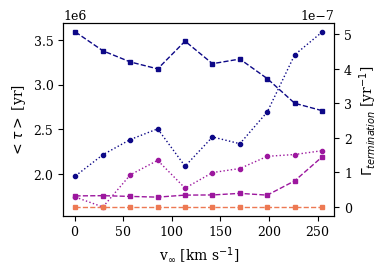

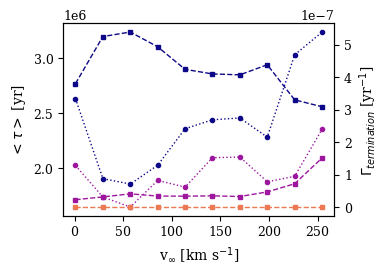

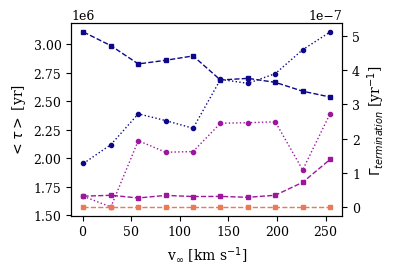

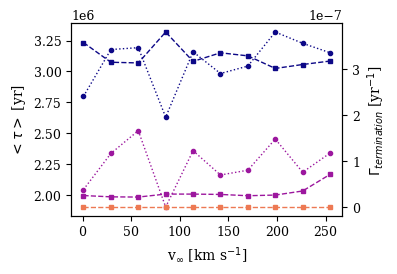

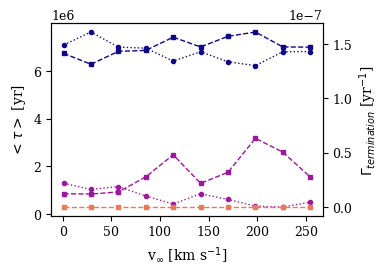

In [98]:
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    name = analysis.name
    plotobj = pl.Plots(name=name, analysis=[analysis])
    mlist1 = ['total_rate','ejection_rate','collision_rate']
    mlabels1 = ['Total', 'Ejected', 'Collided']
    mylabel1 =r'$\Gamma_{termination}$ [yr$^{-1}$]'
    mlist3 = ['average_lifetime_total','average_lifetime_ejected','average_lifetime_collided']
    mlabels3 = ['Total', 'Ejected', 'Collided']
    mylabel3 =r'$<\tau>$ [yr]'
    mlists = [mlist3, mlist1]
    mlabels = [mlabels3, mlabels1]
    mylabels = [mylabel3, mylabel1]
    plotobj.plot_metric_wrt_v_twinaxis(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=None, analysis_name=name, save=False)

In [63]:
analysis_list = []
for run in runs_dict.keys():
    analysis = runs_dict[run]['analysis']
    analysis_list.append(analysis)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in mc: shape=()
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts
✓ Found in termination_counts


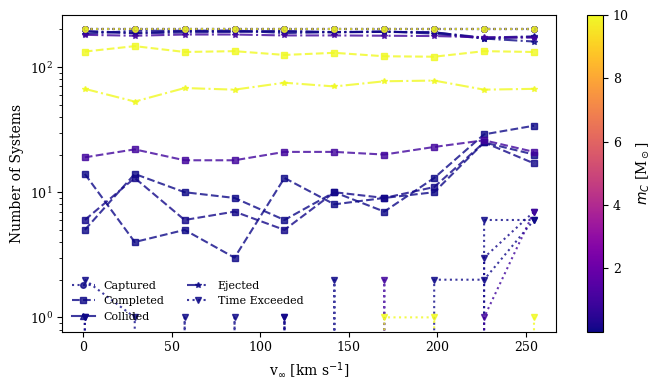

In [64]:
plotobj2 = pl.Plots(name="OCenturi", analysis=analysis_list, exclude_zero_capture=True)
metric_list = ['n_captured', 'completed_count', 'collision_count_rebound', 'escape_C_count', 'time_exceeded_count']
metric_labels = ['Captured', 'Completed', 'Collided', 'Ejected', 'Time Exceeded']
mylabel = 'Number of Systems'
plotobj2.multiple_analysis_metric_wrt_v(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', save=True)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in mc: shape=()
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in termination_counts
✓ Found in an_entry
✓ Found in

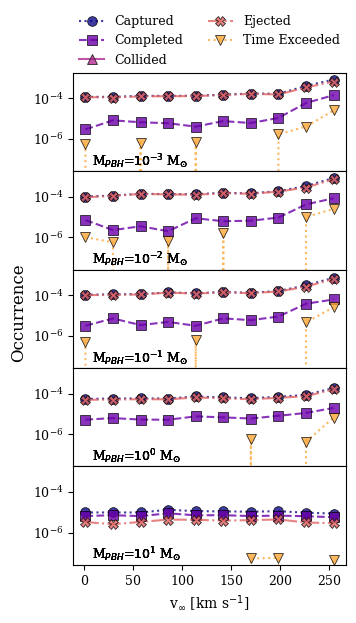

In [65]:
mylabel = 'Occurrence'
plotobj2.multiple_analysis_metric_wrt_v_multipanel(metric_list=metric_list, metric_ylabel=mylabel, metric_labels=metric_labels, analysis_key= 'All', v_key='All', normalize='sample_count', save=True,fig_size=(3.5,6))

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Found in rebound: 200 entries
✓ Fo

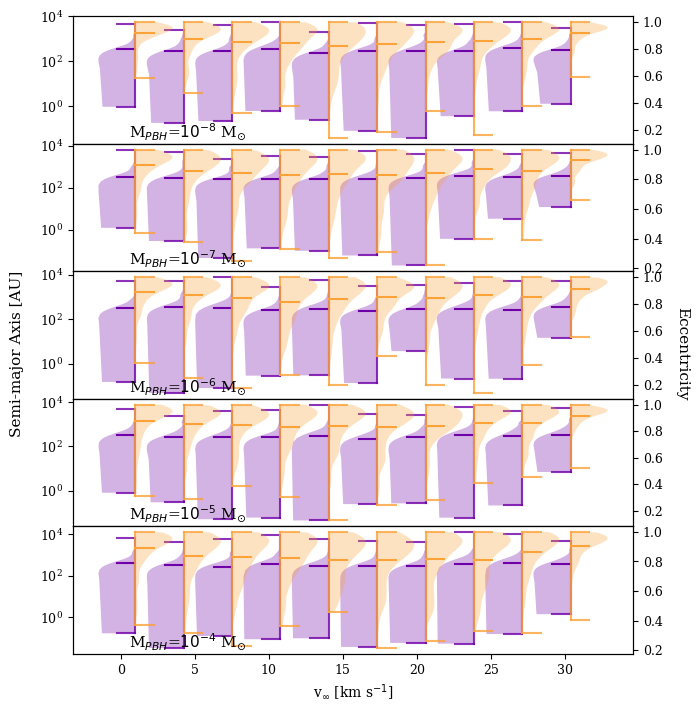

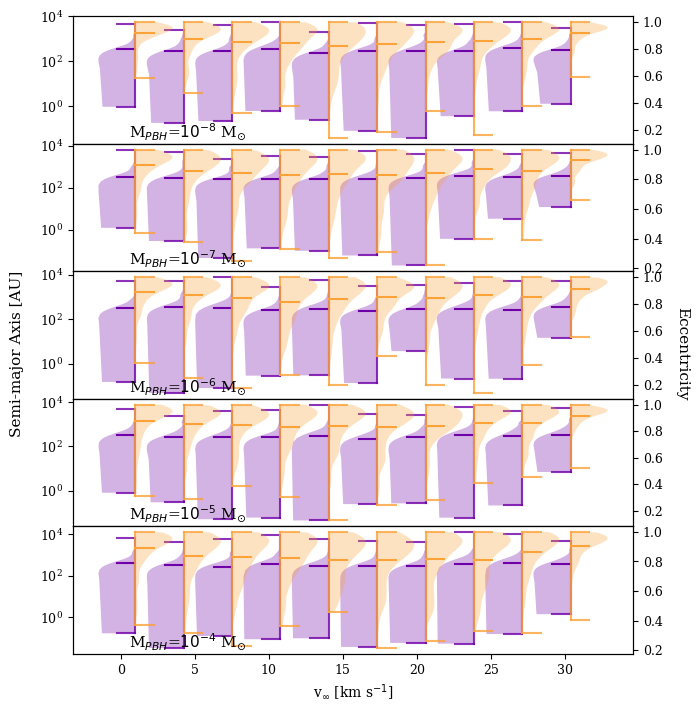

In [16]:
mlist_left = ['semi_major_axes']
mlist_right = ['eccentricities']
mlabels_left = 'Semi-major Axis [AU]'
mlabels_right = 'Eccentricity'

plotobj2.multiple_analysis_metric_array_wrt_v_twinaxis_multipanel(
    metric_lists=[mlist_left, mlist_right],
    metric_ylabels=[mlabels_left, mlabels_right],
    scale=['log','linear'],
    analysis_key='All',
    v_key='All',
    global_ylim=False,
    save=True
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ Found in occurrences
✓ F

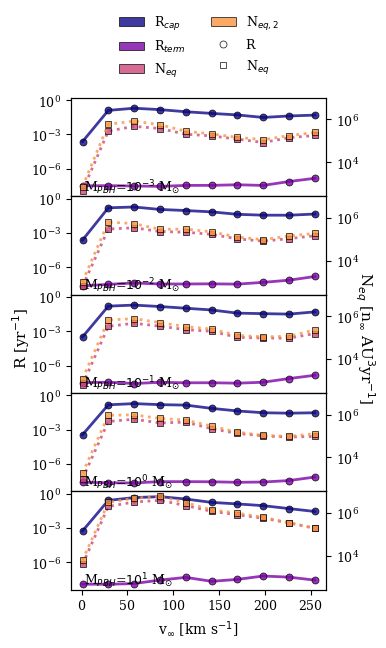

In [93]:
mlist0 = ['capture_rate', 'termination_rate']
mlabels0 = ['R$_{cap}$', 'R$_{term}$']
mylabel0 =r'R [yr$^{-1}$]'
mlist1 = ['total_systems_neq', 'total_systems_neq_2']
mlabels1 = ['N$_{eq}$', 'N$_{eq,2}$']
mylabel1 =r'N$_{eq}$ [n$_\infty$ AU$^{3}$yr$^{-1}$]'
mlists = [mlist0, mlist1]
mlabels = [mlabels0, mlabels1]
mylabels = [mylabel0, mylabel1]
plotobj2.multiple_analysis_metric_wrt_v_twinaxis_multipanel(metric_lists=mlists, metric_ylabels=mylabels, metric_labels=mlabels, scale=['linear', 'log', 'log'], analysis_key= 'All', v_key='All', global_ylim=True, match_colors=False, unit_change=[1e-3, 1, 1], normalize=False, save=True, fig_size=(3.5,6))

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


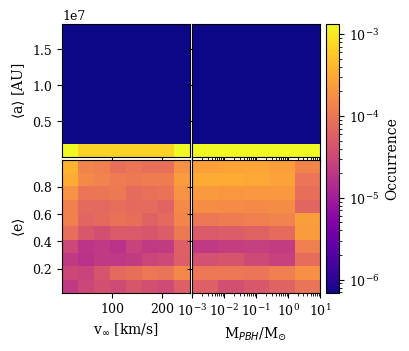

In [69]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$e$\rangle$'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[8, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    save_as="a_e_averages_histogram.png",
    fig_size=(4, 3.5)
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


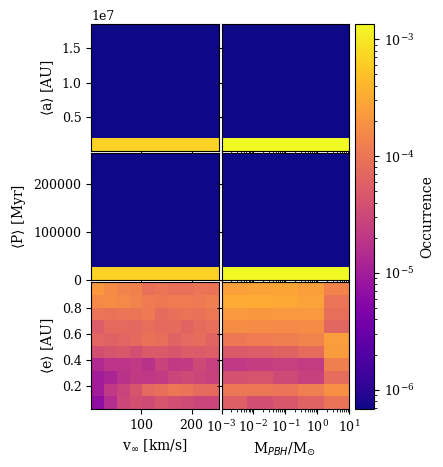

In [94]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'orbital_periods', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$P$\rangle$ [Myr]', r'$\langle$e$\rangle$ [AU]'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[10, 5],
    metric_bins=10,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1e-6, 1], [1, 1, 1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None, None],
    normalize='total_sample_count',
    normalize_annotation='capture_count',
    annotate_bins=False,
    metric_masks=[
        None,  # No mask for semi_major_axes
        None,  # No mask for orbital_periods
        None
    ],
    save='a_P_e_2dhist.png',  # ← Don't save until we confirm it works
    fig_size=(4, 5)
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/grad/a.saricaoglu/.conda/envs/captus/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v57, sum=2
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v86, sum=1
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v114, sum=1
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v142, sum=1
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v170, sum=1
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v198, sum=4
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v226, sum=7
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at v=v255, sum=9
✓ Found in rebound: 200 entries
✓ Found in an_entry
Axis 1: Applying mask for 'semi_major_axes' at

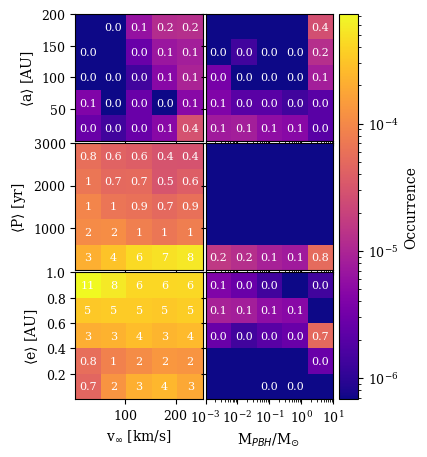

In [95]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['semi_major_axes', 'orbital_periods', 'eccentricities'],        # ← Keyword arg
    metric_ylabel=[r'$\langle$a$\rangle$ [AU]', r'$\langle$P$\rangle$ [yr]', r'$\langle$e$\rangle$ [AU]'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[5, 5],
    metric_bins=5,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=[[1e-6, 200], [1e-6, 3000], [1e-6, 1]],  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None, None],
    normalize='total_sample_count',
    normalize_annotation='capture_count',
    annotate_bins=True,
    metric_masks=[
        None,  # No mask for semi_major_axes
        {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    },  # No mask for orbital_periods
    {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }
    ],
    save='a_P_e_2dhist_masked_limited.png',  # ← Don't save until we confirm it works
    fig_size=(4, 5)
)

In [250]:
print(np.round(5.08, 1))

5.1


✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


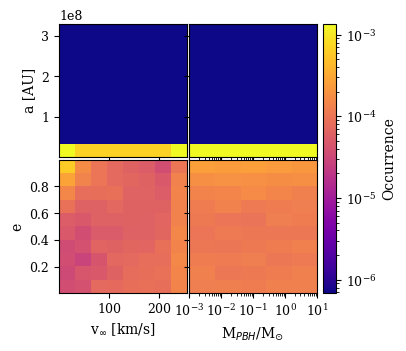

In [96]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['a_au', 'e'],        # ← Keyword arg
    metric_ylabel=[r'a [AU]', r'e'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[8, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=None,  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=None,
    save=True,  # ← Don't save until we confirm it works
    save_as="initial_a_e_histogram.png",
    fig_size=(4,3.5)
)

✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry
✓ Found in an_entry


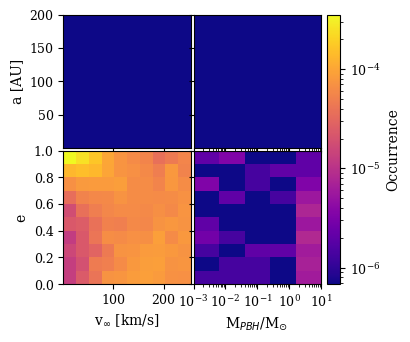

In [97]:
plotobj2.multiple_analysis_voxel_2dhistogram(
    metric_name=['a_au', 'e'],        # ← Keyword arg
    metric_ylabel=[r'a [AU]', r'e'],
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_\infty$ [km/s]', r'M$_{PBH}$/M$_{\odot}$ '],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=[[['linear', 'linear', 'log'], ['log', 'linear', 'log']], [['linear', 'linear', 'log'], ['log', 'linear', 'log']]],
    v_key='All',
    global_ylim=False,
    voxel_bins=[10, 5],
    metric_bins=10,
    annotate_bins=False,
    custom_voxel_bins=False,
    voxel_range=None,
    metric_range=[[1e-6, 200], [0, 1]],  # ← Add explicit range to avoid outliers
    unit_change=[[[1e-3, 1, 1], [1,1 ,1]], [[1e-3, 1, 1], [1, 1, 1]]],
    v_lim=[None, None],
    normalize='total_sample_count',
    metric_masks=[None, 
                      {
        "type": "where",
        "key": "semi_major_axes",  # Time series of semi-major axes
        "predicate": lambda a_arr: np.mean(a_arr) <= 200.0  # Average a over time
    }],
    save=True,  # ← Don't save until we confirm it works
    save_as="initial_a_e_histogram_limited.png",
    fig_size=(4,3.5)
)

In [19]:
# Test on one entry
d = analysis_list[0].get_combined_dictionary()
entry = d['v1']

print("Entry keys:", entry.keys())
print("\nTrying to get a_au:")
result = plotobj4._get_metric_from_sources(entry, 'a_au')
print(f"Result type: {type(result)}")
print(f"Result: {result if not isinstance(result, np.ndarray) else f'array with shape {result.shape}'}")

print("\n\nMC content:")
mc = entry.get('mc')
if mc is not None:
    print(f"mc type: {type(mc)}")
    if hasattr(mc, 'files'):
        print(f"mc.files: {mc.files}")
    elif isinstance(mc, dict):
        print(f"mc.keys(): {mc.keys()}")
    
    # Try direct access
    if hasattr(mc, 'files') and 'a_au' in mc.files:
        print(f"\nDirect mc['a_au']: {mc['a_au'].shape}")
    elif isinstance(mc, dict) and 'a_au' in mc:
        print(f"\nDirect mc['a_au']: {np.shape(mc['a_au'])}")

Entry keys: dict_keys(['v_inf_m_s', 'v_inf_au_yr', 'mC', 'importance_sampling_size', 'sample_count', 'capture_count', 'sampled_capture_count', 'mc', 'rebound', 'sampled_mc', 'termination_counts', 'masks', 'occurrences', 'ej_mask', 'coll_mask'])

Trying to get a_au:
Searching for metric "a_au"...
Result type: <class 'numpy.ndarray'>
Result: array with shape (0,)


MC content:
mc type: <class 'numpy.lib.npyio.NpzFile'>
mc.files: ['v_inf', 'n_captured', 'sigma_MC_m2', 'sigma_MC_areaB', 'a_au', 'e', 'cap_lambda', 'cap_beta', 'cap_b', 'cap_phi', 'epsilon', 'sample_number', 'execution_time']

Direct mc['a_au']: (200,)


Axis 0: Collected 16287 data points for 'orbital_periods'
Axis 1: Collected 16287 data points for 'orbital_periods'


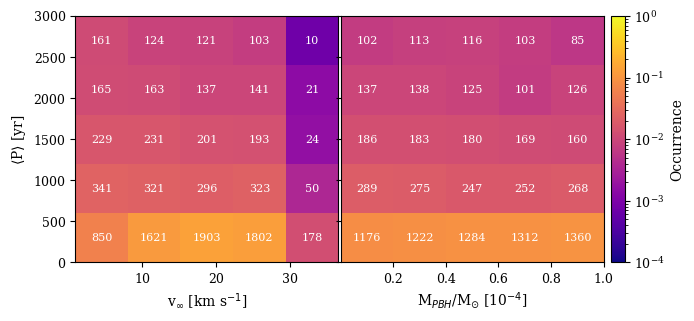

In [143]:
plotobj4.multiple_analysis_voxel_2dhistogram(
    metric_name='orbital_periods',        # ← Keyword arg
    metric_ylabel=r'$\langle$P$\rangle$ [yr]', # ← Keyword arg
    voxel_name=['v_inf_m_s', 'mC'],
    voxel_xlabel=[r'v$_{\infty}$ [km s$^{-1}$]', r'M$_{PBH}$/M$_{\odot}$ [10$^{-4}$]'],
    analysis_key='All',
    analysis_zkey='mC',
    analysis_zlabel=[r'M$_{PBH}$', r'M$_{\odot}$'],
    scale=['linear', 'linear', 'log'],
    v_key='All',
    global_ylim=False,
    voxel_bins=5,
    metric_bins=5,
    voxel_range=None,
    metric_range=[0, 3000],
    unit_change=[[1e-3, 1, 1], [1e4, 1, 1]],
    v_lim=[1e-4, 1],
    normalize='sample_count',
    annotate_bins=True,
    save=True
)